# Import Libraries

In [1]:
%matplotlib ipympl
from time import time
import scipy.cluster.hierarchy as spc
from pennylane import numpy as pnp
import pennylane as qml
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
# set style matplotlib
sns.set_style("whitegrid")

C:\Users\mathi\AppData\Local\Temp\ipykernel_21040\2355560971.py:3: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.4)
  import scipy.cluster.hierarchy as spc


# Data Import

### Creating column names based on the readme file

In [ ]:
operational_settings = ['op_setting_{}'.format(i + 1) for i in range(3)]
sensor_columns = ['sensor_{}'.format(i + 1) for i in range(27)]
features = operational_settings + sensor_columns
metadata = ['engine_no', 'time_in_cycles']
list_columns = metadata + features

 ### Importing training data and adding headers to the table

In [ ]:
df = pd.read_csv('./CMAPSSData/train_FD001.txt', sep=' ',
                 header=None, names=list_columns)
df.head(2)

,engine_no,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388,100.0,39.06,23.4190,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388,100.0,39.00,23.4236,NaN,NaN,NaN,NaN,NaN,NaN


# Data preprocessing

### Adding RUL column and reorganizing the df

In [ ]:
df_max_life = df.groupby('engine_no')['time_in_cycles'].max().reset_index()
df_max_life.rename(columns={'time_in_cycles': 'Max Life'}, inplace=True)
df = df.merge(df_max_life, on=['engine_no'], how='left')
df['RUL'] = df['Max Life'] - df['time_in_cycles']

df

,engine_no,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,Max Life,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,39.06,23.4190,NaN,NaN,NaN,NaN,NaN,NaN,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,39.00,23.4236,NaN,NaN,NaN,NaN,NaN,NaN,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,38.95,23.3442,NaN,NaN,NaN,NaN,NaN,NaN,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,38.88,23.3739,NaN,NaN,NaN,NaN,NaN,NaN,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,38.90,23.4044,NaN,NaN,NaN,NaN,NaN,NaN,192,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,38.49,22.9735,NaN,NaN,NaN,NaN,NaN,NaN,200,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,38.30,23.1594,NaN,NaN,NaN,NaN,NaN,NaN,200,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,38.44,22.9333,NaN,NaN,NaN,NaN,NaN,NaN,200,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,38.29,23.0640,NaN,NaN,NaN,NaN,NaN,NaN,200,1


### Deleting NaN and constant columns

In [ ]:
for col in df.columns:
    if len(df[col].unique()) == 1:
        df.drop(col, inplace=True, axis=1)

### Using Pearson correlation matrix choosing top 4 most correlated indicators

### Deleting irrelevant data from training set

```python 
df.drop(['op_setting_1', 'op_setting_2', 'engine_no', 'time_in_cycles'],inplace=True,axis=1)

## Normalize data

In [ ]:
for col in df.columns:
    if col != 'engine_no':
        df[col] = (df[col]-df[col].min())/(df[col].max() - df[col].min())

# Correlation analysis

### Pearson Matrix

In [ ]:
pearson = df.copy()
pearson.drop(['engine_no', 'time_in_cycles', 'Max Life'], axis=1, inplace=True)
pearson = pearson.corr(method='pearson')

### Define cutoff

In [ ]:
max_distance = 0.1

### Dendrogram

In [ ]:
def fancy_dendrogram(*args, **kwargs):
    max_d = kwargs.pop('max_d', None)
    if max_d and 'color_threshold' not in kwargs:
        kwargs['color_threshold'] = max_d
    annotate_above = kwargs.pop('annotate_above', 0)

    ddata = spc.dendrogram(*args, **kwargs)

    if not kwargs.get('no_plot', False):
        plt.title('Hierarchical Clustering Dendrogram (truncated)')
        plt.xlabel('sample index or (cluster size)')
        plt.ylabel('distance')
        for i, d, c in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
            x = 0.5 * sum(i[1:3])
            y = d[1]
            if y > annotate_above:
                plt.plot(x, y, 'o', c=c)
                plt.annotate("%.3g" % y, (x, y), xytext=(0, -5),
                             textcoords='offset points',
                             va='top', ha='center')
        if max_d:
            plt.axhline(y=max_d, c='k')
    return ddata

### Pearson Heatmap

Text(0.5, 1.0, 'Pearson Correlation Heatmap')

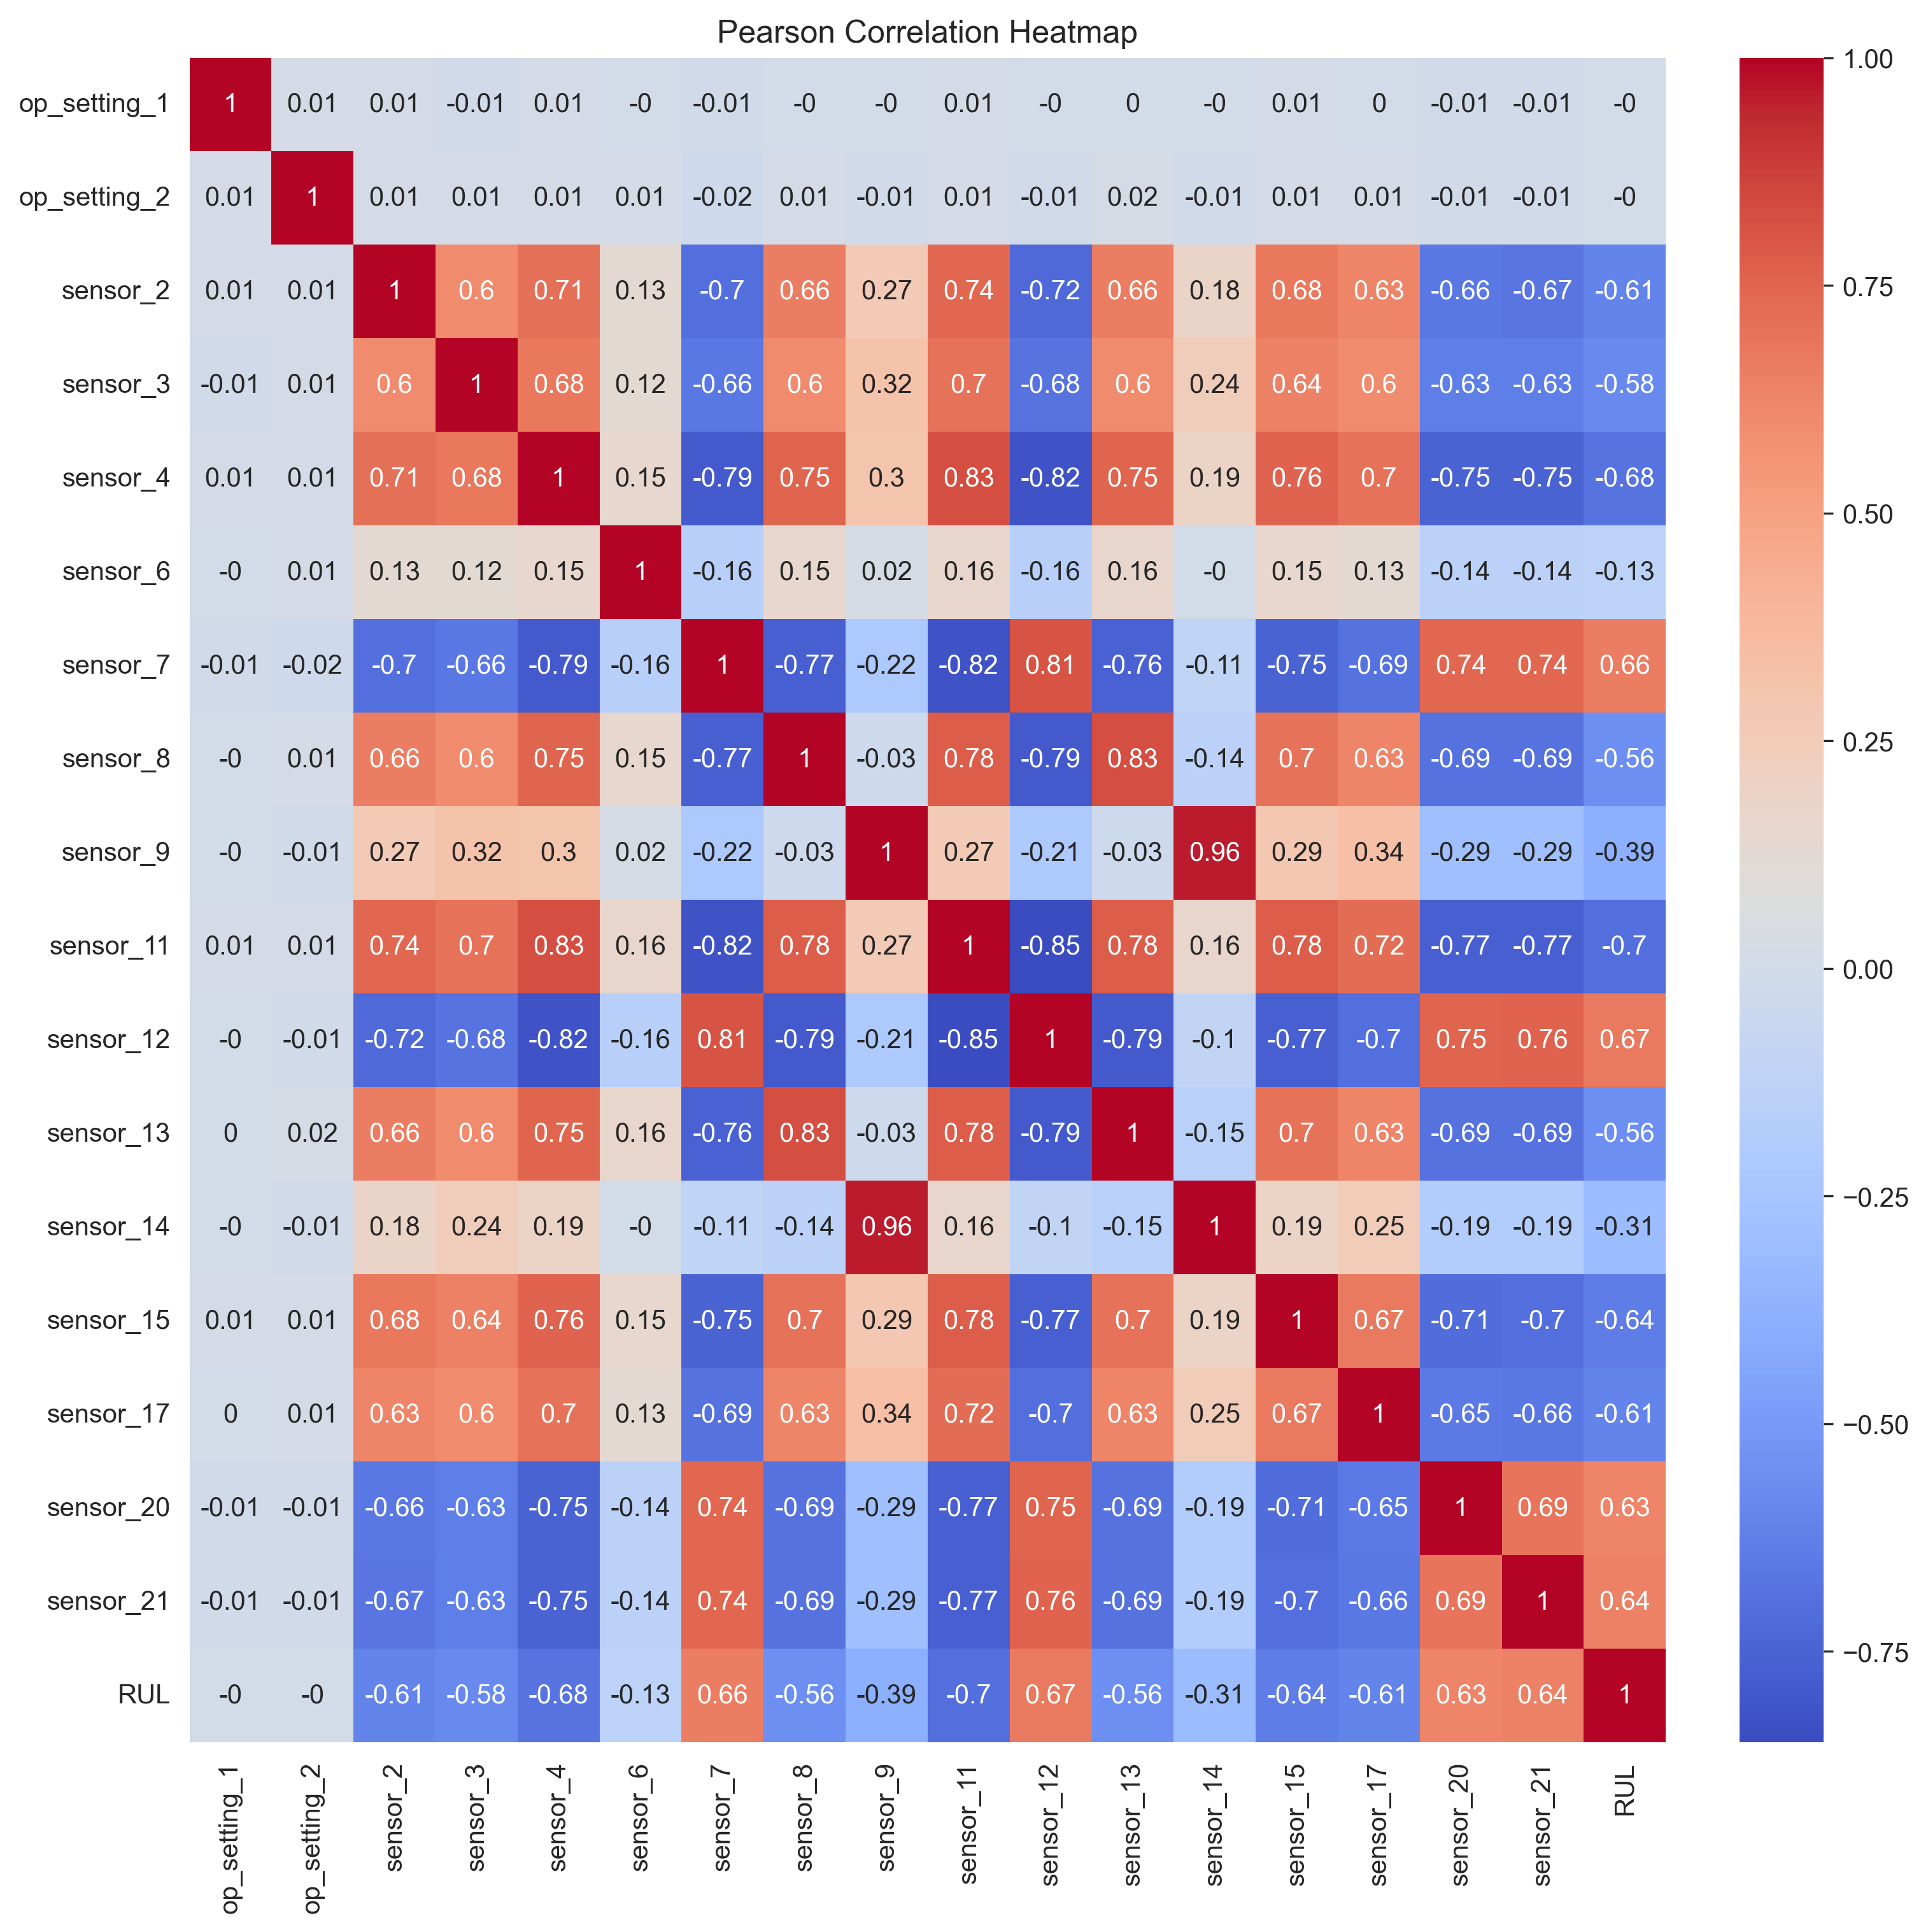

In [ ]:
fig, axes = plt.subplots(figsize=(10, 10), layout='constrained',
                         dpi=300
                         )
sns.heatmap(pearson.round(2), annot=True, cmap='coolwarm', fmt='.2g', ax=axes)
axes.set_title('Pearson Correlation Heatmap')

,Feature,Correlation
0,RUL,1.000000
1,sensor_11,0.696228
2,sensor_4,0.678948
3,sensor_12,0.671983
4,sensor_7,0.657223
5,sensor_15,0.642667
6,sensor_21,0.635662
7,sensor_20,0.629428
8,sensor_2,0.606484
9,sensor_17,0.606154


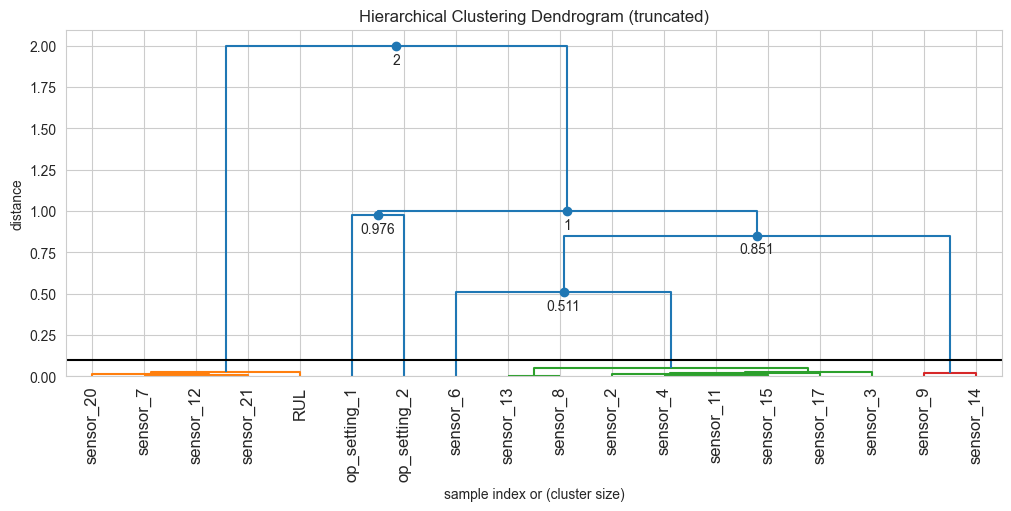

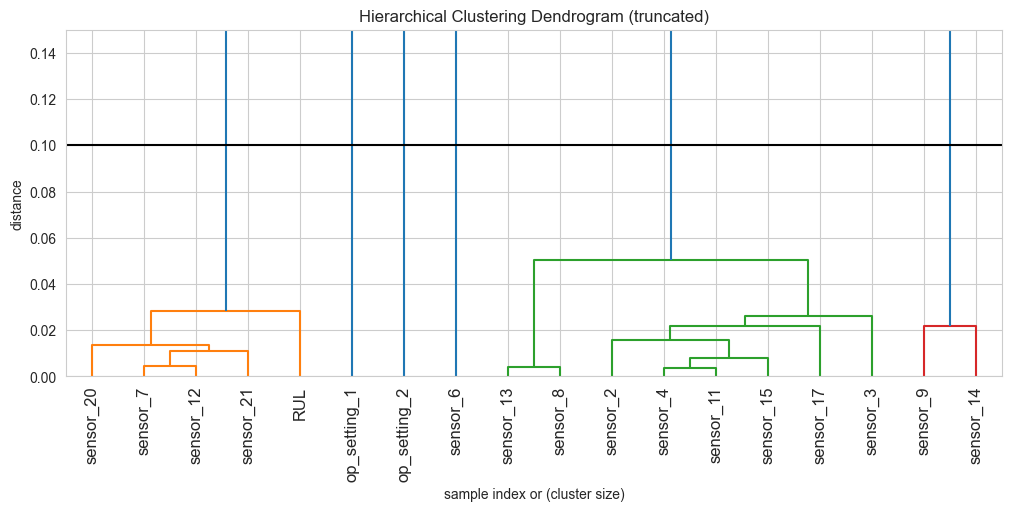

In [ ]:
linkage_corr = spc.linkage(pearson, method='complete',
                           metric='cosine', optimal_ordering=True)

fig, axes = plt.subplots(figsize=(10, 5), layout='constrained',
                         # dpi=150
                         )
tree = fancy_dendrogram(linkage_corr,
                        # orientation='left',
                        p=100,
                        labels=pearson.columns.tolist(),
                        show_leaf_counts=True,
                        show_contracted=True,
                        leaf_rotation=90,
                        max_d=max_distance,
                        annotate_above=0.09,
                        ax=axes)

fig, axes = plt.subplots(figsize=(10, 5), layout='constrained',
                         # dpi=150
                         )
tree = fancy_dendrogram(linkage_corr,
                        # orientation='left',
                        p=100,
                        labels=pearson.columns.tolist(),
                        show_leaf_counts=True,
                        show_contracted=True,
                        leaf_rotation=90,
                        max_d=max_distance,
                        annotate_above=0.09,
                        ax=axes)

axes.set_ylim(0, max_distance + 0.05)

RUL_corr = pearson.abs().sort_values('RUL', ascending=False)['RUL'].reset_index(
    drop=False).rename(columns={'RUL': 'Correlation', 'index': 'Feature'})
RUL_corr

### Clusters

In [ ]:
clusters = spc.fcluster(linkage_corr, t=max_distance, criterion='distance')

clustered_features = {}
for feature, cluster_id in zip(pearson.columns, clusters):
    clustered_features.setdefault(cluster_id, []).append(feature)

clustered_features

{2: ['op_setting_1'],
 3: ['op_setting_2'],
 4: ['sensor_2',
  'sensor_3',
  'sensor_4',
  'sensor_8',
  'sensor_11',
  'sensor_13',
  'sensor_15',
  'sensor_17'],
 5: ['sensor_6'],
 1: ['sensor_7', 'sensor_12', 'sensor_20', 'sensor_21', 'RUL'],
 6: ['sensor_9', 'sensor_14']}

In [ ]:
selected_features = []
for cluster_id, features in clustered_features.items():
    features = [x for x in features if x != 'RUL']
    if features:
        # Select the feature from this cluster with the highest correlation to RUL
        feature = RUL_corr[RUL_corr['Feature'].isin(features)].sort_values(
            'Correlation', ascending=False)['Feature'].iloc[0]
        selected_features.append(feature)

selected_features

['op_setting_1',
 'op_setting_2',
 'sensor_11',
 'sensor_6',
 'sensor_12',
 'sensor_9']